# Day 1: NumPy & Pandas Mastery for ML

**Dataset:** Titanic (seaborn built-in) — 891 passengers
**Goal:** Full data profiling — info, describe, missing-value map, dtype audit

*Note: Using seaborn's built-in Titanic dataset since UCI Diabetes is currently unavailable. The profiling techniques are identical.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load the Titanic dataset from seaborn (built-in, no download needed)
df = sns.load_dataset('titanic')
print(f"Loaded Titanic dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded Titanic dataset: 891 rows, 15 columns


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# 1. Basic info — shape, dtypes, non-null counts
if df is not None:
    print("=== SHAPE ===")
    print(df.shape)
    print("\n=== DTYPES ===")
    print(df.dtypes.value_counts())
    print("\n=== DF.INFO() ===")
    df.info()

=== SHAPE ===
(891, 15)

=== DTYPES ===
object      5
int64       4
float64     2
bool        2
category    1
category    1
Name: count, dtype: int64

=== DF.INFO() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool

In [4]:
# 2. Statistical summary — describe() for numeric + object columns
if df is not None:
    print("=== NUMERIC DESCRIBE ===")
    print(df.describe())
    print("\n=== CATEGORICAL DESCRIBE ===")
    print(df.describe(include='object'))

=== NUMERIC DESCRIBE ===
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200

=== CATEGORICAL DESCRIBE ===
         sex embarked  who  embark_town alive
count    891      889  891          889   891
unique     2        3    3            3     2
top     male        S  man  Southampton    no
freq     577      644  537          644   549


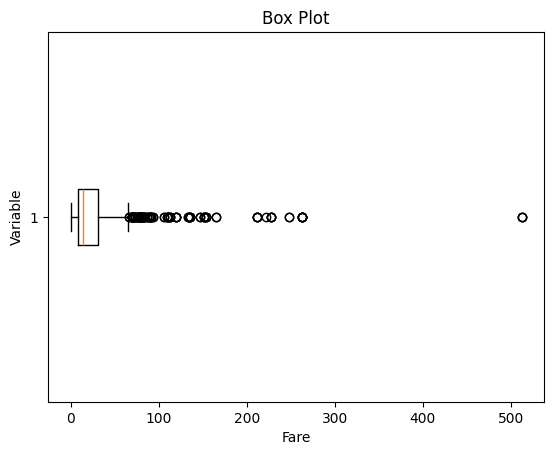

In [21]:
plt.boxplot(df['fare'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Fare')
plt.title('Box Plot')
plt.show()

=== MISSING VALUES ===
             missing_count  missing_pct
deck                   688        77.22
age                    177        19.87
embarked                 2         0.22
embark_town              2         0.22


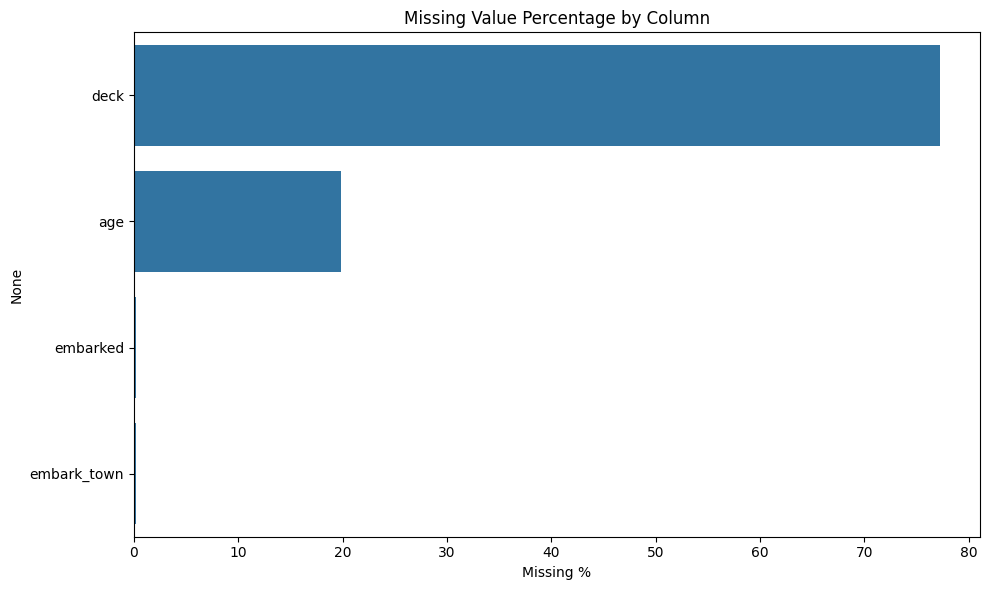

In [5]:
# 3. Missing value analysis
if df is not None:
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
    missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
    print("=== MISSING VALUES ===")
    print(missing_df)
    
    # Visualize missingness
    if len(missing_df) > 0:
        plt.figure(figsize=(10, 6))
        sns.barplot(x=missing_df['missing_pct'], y=missing_df.index)
        plt.title('Missing Value Percentage by Column')
        plt.xlabel('Missing %')
        plt.tight_layout()
        plt.show()

In [6]:
# 4. Dtype audit — check for columns that should be categorical vs numeric
print("=== OBJECT COLUMNS (potential categoricals) ===")
obj_cols = df.select_dtypes(include='object').columns
for col in obj_cols:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} unique values")
    if n_unique < 20:
        print(f"  Values: {df[col].unique()}")

=== OBJECT COLUMNS (potential categoricals) ===
sex: 2 unique values
  Values: ['male' 'female']
embarked: 3 unique values
  Values: ['S' 'C' 'Q' nan]
who: 3 unique values
  Values: ['man' 'woman' 'child']
embark_town: 3 unique values
  Values: ['Southampton' 'Cherbourg' 'Queenstown' nan]
alive: 2 unique values
  Values: ['no' 'yes']


In [7]:
# 5. Target variable exploration (survived)
if 'survived' in df.columns:
    print("=== TARGET: survived ===")
    print(df['survived'].value_counts())
    print(df['survived'].value_counts(normalize=True).round(4))
    
    # Check for '?' or other placeholder values in object columns
    obj_cols = df.select_dtypes(include='object').columns
    for col in obj_cols:
        if '?' in df[col].values:
            print(f"\nColumn '{col}' contains '?' placeholders:")
            print(df[col].value_counts())

=== TARGET: survived ===
survived
0    549
1    342
Name: count, dtype: int64
survived
0    0.6162
1    0.3838
Name: proportion, dtype: float64


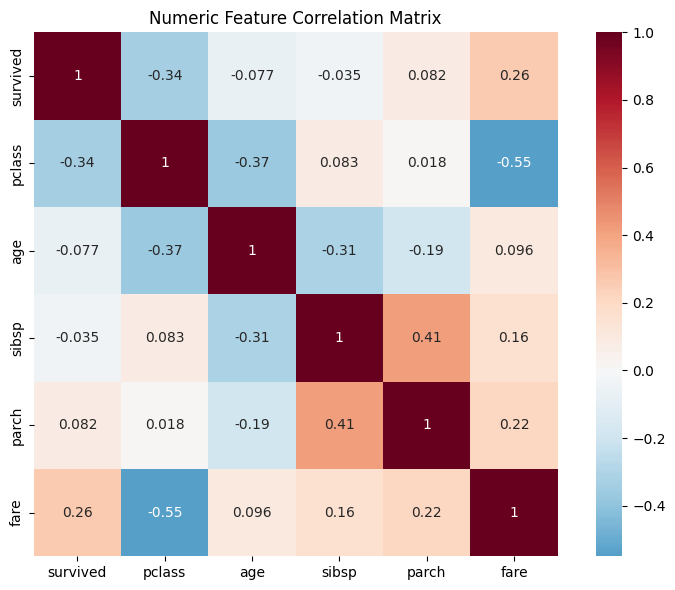

In [18]:
# 6. Correlation heatmap for numeric features (optional stretch)
numeric_df = df.select_dtypes(include=[np.number])
if len(numeric_df.columns) > 1:
    plt.figure(figsize=(8, 6))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, square=True)
    plt.title('Numeric Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()

## Summary Notes

- Dataset shape: 
- Key missing columns: 
- Target distribution: 
- Notable dtype issues: 
- Questions for tomorrow's cleaning session: 